In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression   
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
data = pd.read_csv("train.csv")

In [13]:
data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
270,271,0,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S
730,731,1,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S
615,616,1,2,"Herman, Miss. Alice",female,24.0,1,2,220845,65.0000,NaN,S
430,431,1,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,0,0,110564,26.5500,C52,S
378,379,0,3,"Betros, Mr. Tannous",male,20.0,0,0,2648,4.0125,NaN,C


In [14]:
data = data[["Survived","Pclass","Sex","Age","Fare","SibSp","Parch"]]


,Survived,Pclass,Sex,Age,Fare,SibSp,Parch
0,0,3,male,22.0,7.2500,1,0
1,1,1,female,38.0,71.2833,1,0
2,1,3,female,26.0,7.9250,0,0
3,1,1,female,35.0,53.1000,1,0
4,0,3,male,35.0,8.0500,0,0
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,0,0
887,1,1,female,19.0,30.0000,0,0
888,0,3,female,NaN,23.4500,1,2
889,1,1,male,26.0,30.0000,0,0


In [15]:
data["Sex"] = data["Sex"].map({"male":0,"female":1})

In [16]:
print(data.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
SibSp         0
Parch         0
dtype: int64


In [25]:
data.fillna({"Age": data["Age"].median()}, inplace=True)

# data

,Survived,Pclass,Sex,Age,Fare,SibSp,Parch
0,0,3,0,22.0,7.2500,1,0
1,1,1,1,38.0,71.2833,1,0
2,1,3,1,26.0,7.9250,0,0
3,1,1,1,35.0,53.1000,1,0
4,0,3,0,35.0,8.0500,0,0
...,...,...,...,...,...,...,...
886,0,2,0,27.0,13.0000,0,0
887,1,1,1,19.0,30.0000,0,0
888,0,3,1,28.0,23.4500,1,2
889,1,1,0,26.0,30.0000,0,0


In [26]:
print(data.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
SibSp       0
Parch       0
dtype: int64


In [27]:
X = data.drop("Survived",axis=1)
y = data["Survived"]

In [28]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
model = LogisticRegression(max_iter=1000,penalty='l2')
model.fit(x_train,y_train)

c:\Users\patel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [30]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]
#print(y_pred)
#print(y_prob)

In [31]:
print("Accu",accuracy_score(y_test,y_pred))

Accu 0.8100558659217877


In [32]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[92 13]
 [21 53]]


In [33]:
new_pass = pd.DataFrame({
    'Pclass':[2],
    'Sex':[1],
    'Age':[25],
    'Fare':[50],
    'SibSp':[0],
    'Parch':[1]
})

In [34]:
predict = model.predict(new_pass)
prob = model.predict_proba(new_pass)
print(predict)
print(prob[0][1])

[1]
0.8376962037291014


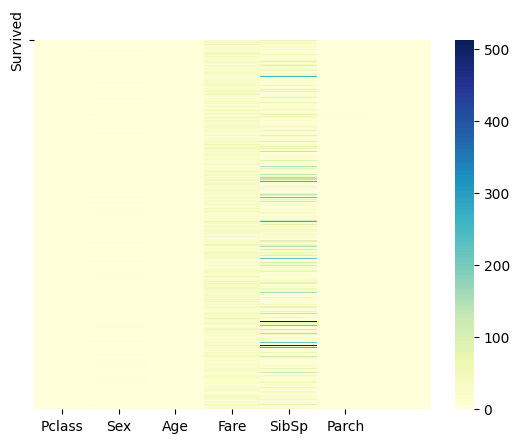

In [43]:
y = ["Pclass","Sex","Age","Fare","SibSp","Parch"]
survive = ["Survived"]

sns.heatmap(data,annot=False,cmap="YlGnBu",xticklabels=y,yticklabels=survive)
plt.show()

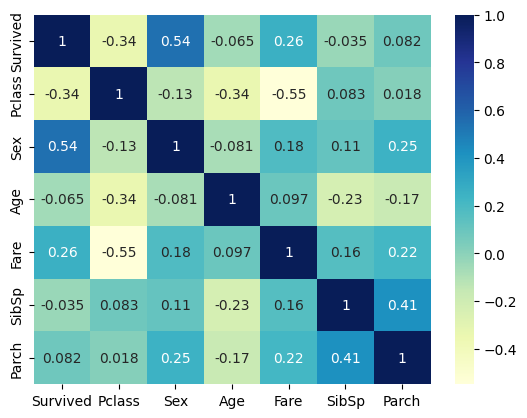

In [44]:
heatmap = sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")
plt.show()